Deep Learning is a subset of ML which uses neural networks it is inspired from the stucture and functions of the neural network of the human brain.It is able to work on huge amount of data it can solve complex problems and can autimatically extract the feature and patterns from the data.
In ML training training is fast and testing is compatively slow where as in deep learning training is very slow and testing is fast.

w1,w2,w3....wn represents the weights which shows the strength of a particular node 
b represents the bias value it allows us to move or to shift the activation function up or down,then the products are summed then fed to the activation function to generate a result and this result is same as output.

Activation function it decides whether a neuron is activated or not my calculationg the weighted sum and further add the bias to it. 
Linear-for continous data            fn range
Sigmoid-for catogorical
TanH(Hyperbolic tangent)-for catogorical
ReLU(Rectified Linear unit)-for catogorical and continous it converts all the neg number into zero and keep all the positive number as it is 


Loss Function:-
1)regeression:-
  1)mean squared error
  2)mean absolute error
2)classification
  1)binary crossentropy 
  2)catogorical crossentropy 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [3]:
ad=pd.read_csv(r"C:\Users\mishr\OneDrive\Desktop\advertising.csv")
ad

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [4]:
ip=ad.drop('Sales',axis=1)
ip

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [5]:
op=ad.Sales
op

0      22.1
1      10.4
2      12.0
3      16.5
4      17.9
       ... 
195     7.6
196    14.0
197    14.8
198    25.5
199    18.4
Name: Sales, Length: 200, dtype: float64

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    ip,
    op,
    train_size=0.8,
    random_state=3000
)

In [7]:

from sklearn.preprocessing import StandardScaler

sc = StandardScaler() 
x_train = sc.fit_transform(x_train) 

x_test = sc.transform(x_test) 

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.21.0


In [9]:
# Model training 
model = Sequential()
# Input layer & first hidden layer
model.add(Dense(30,input_dim=3,activation="linear"))   # first 30 hidden layers, dimension 3 , then input layer
model.add(Dense(25, activation="linear"))              # 25 neurons
model.add(Dense(10, activation="linear"))              # 20 neurons
model.add(Dense(1, activation="linear"))               # 1 neuron # Output layer
model.compile(Adam(learning_rate=0.01),loss="mse")

C:\Users\mishr\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 30)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │           775 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           260 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,166 (4.55 KB)

 Trainable params: 1,166 (4.55 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=20)

Epoch 1/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - loss: 235.8433 - val_loss: 207.1116
Epoch 2/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 177.7881 - val_loss: 147.0835
Epoch 3/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 107.7911 - val_loss: 62.1909
Epoch 4/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 33.3116 - val_loss: 3.5481
Epoch 5/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 11.4262 - val_loss: 17.2177
Epoch 6/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 14.9057 - val_loss: 5.3863
Epoch 7/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 4.1624 - val_loss: 3.9689
Epoch 8/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 5.8231 - val_loss: 4.9274
Epoch 9/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 5.0842 - val_loss: 3.7298
Epoch 10/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.4668 - val_loss: 2.1469
Epoch 11/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 3.1080 - val_loss: 2.1215
Epoch 12/20
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 3.5087 - va

In [12]:
y_pred = model.predict(x_test)
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
Mean Squared Error: 2.18
R-squared: 0.92


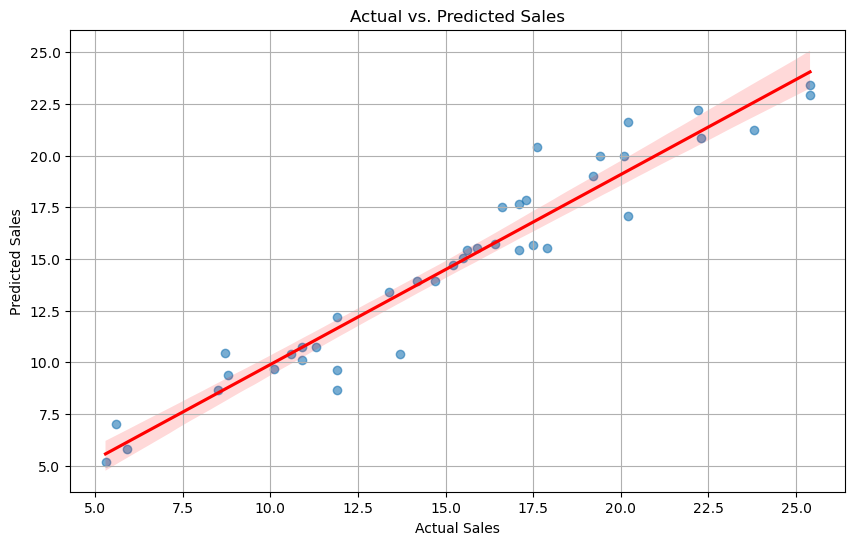

In [13]:
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred.flatten(), scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs. Predicted Sales")
plt.grid(True)
plt.show()

In [14]:
import tensorflow as tf

# This will print out exactly how many GPUs TensorFlow has hijacked for your code
print("Number of GPUs Available to TensorFlow: ", len(tf.config.list_physical_devices('GPU')))

Number of GPUs Available to TensorFlow:  0
